
# UMAP on MNIST (via `sklearn.datasets.fetch_openml`)

This notebook:
- Downloads **MNIST** from OpenML using `sklearn.datasets.fetch_openml` (70,000 images, 784 features).
- Runs **UMAP** (`umap-learn` implementation) to get a 2D embedding.
- Plots the embedding colored by digit label.
- Demonstrates **out-of-sample** embedding via `umap.UMAP.transform` on a held-out split.

> Requirements: `scikit-learn`, `umap-learn`, `matplotlib`, `numpy`.


In [1]:

# If umap-learn is not installed, uncomment the next line to install.
# %pip install umap-learn


In [2]:

SEED = 42
SUBSAMPLE = 10000   # set to None for full 70k (will be slower)
N_NEIGHBORS = 15
MIN_DIST = 0.1
N_COMPONENTS = 2    # 2D embedding
TEST_FRACTION = 0.2 # for out-of-sample transform demo


In [3]:

import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split

import umap.umap_ as umap

np.random.seed(SEED)


/usr/local/Caskroom/miniforge/base/envs/faiss_env/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:

mnist = fetch_openml('mnist_784', version=1, as_frame=False)
X = mnist['data'].astype(np.float32) / 255.0
y = mnist['target'].astype(int)
print("Full dataset:", X.shape, y.shape)


Full dataset: (70000, 784) (70000,)


In [5]:

if SUBSAMPLE is not None and SUBSAMPLE < X.shape[0]:
    idx = np.random.choice(X.shape[0], SUBSAMPLE, replace=False)
    X = X[idx]
    y = y[idx]
print("Using:", X.shape, y.shape)


Using: (10000, 784) (10000,)


In [6]:

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_FRACTION, random_state=SEED, stratify=y
)
print("Train:", X_train.shape, " Test:", X_test.shape)


Train: (8000, 784)  Test: (2000, 784)


In [7]:
%%time
umap_model = umap.UMAP(
    n_neighbors=N_NEIGHBORS,
    min_dist=MIN_DIST,
    n_components=N_COMPONENTS,
    random_state=SEED+5,
    metric='euclidean'
)
Z_train = umap_model.fit_transform(X_train)
print("Embedding shape (train):", Z_train.shape)


/usr/local/Caskroom/miniforge/base/envs/faiss_env/lib/python3.9/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


Embedding shape (train): (8000, 2)
CPU times: user 18.1 s, sys: 771 ms, total: 18.9 s
Wall time: 16 s


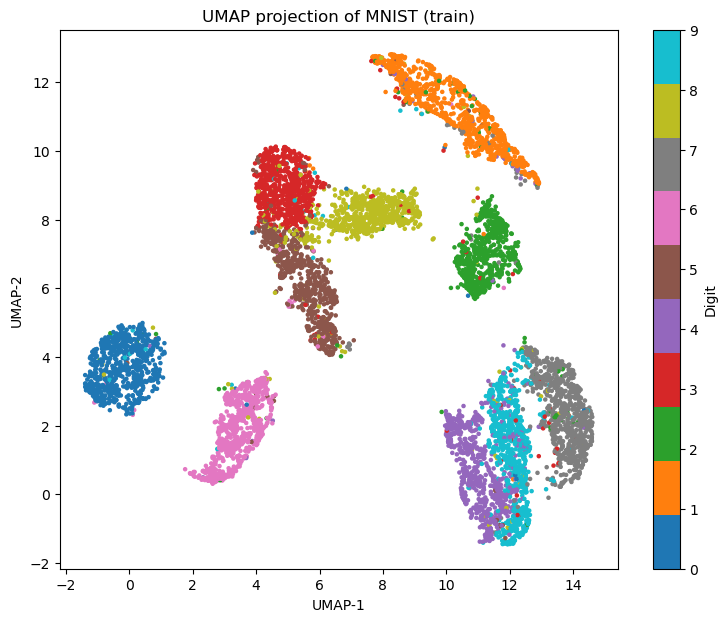

In [8]:

plt.figure(figsize=(9,7))
sc = plt.scatter(Z_train[:,0], Z_train[:,1], c=y_train, s=5, cmap="tab10")
plt.title("UMAP projection of MNIST (train)")
plt.xlabel("UMAP-1")
plt.ylabel("UMAP-2")
cb = plt.colorbar(sc, ticks=range(10))
cb.set_label("Digit")
plt.show()


In [9]:

Z_test = umap_model.transform(X_test)
print("Embedding shape (test):", Z_test.shape)


Embedding shape (test): (2000, 2)


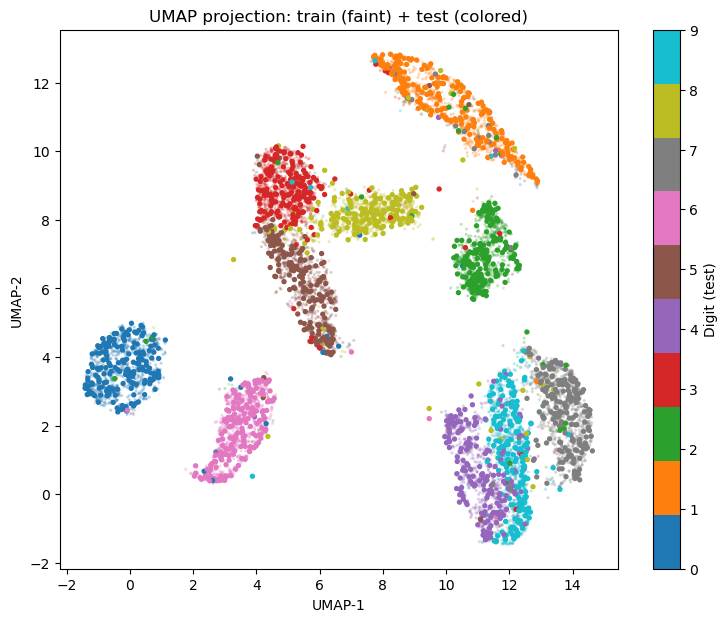

In [10]:

plt.figure(figsize=(9,7))
plt.scatter(Z_train[:,0], Z_train[:,1], c=y_train, s=2, alpha=0.2, cmap="tab10")
sc = plt.scatter(Z_test[:,0], Z_test[:,1], c=y_test, s=8, cmap="tab10")
plt.title("UMAP projection: train (faint) + test (colored)")
plt.xlabel("UMAP-1")
plt.ylabel("UMAP-2")
cb = plt.colorbar(sc, ticks=range(10))
cb.set_label("Digit (test)")
plt.show()



## Notes & Tips
- Use PCA (e.g. 50 dims) before UMAP for speed.
- Try different metrics (`cosine`, `manhattan`) for variety.
- Use `umap_model.transform(new_data)` for out-of-sample points.


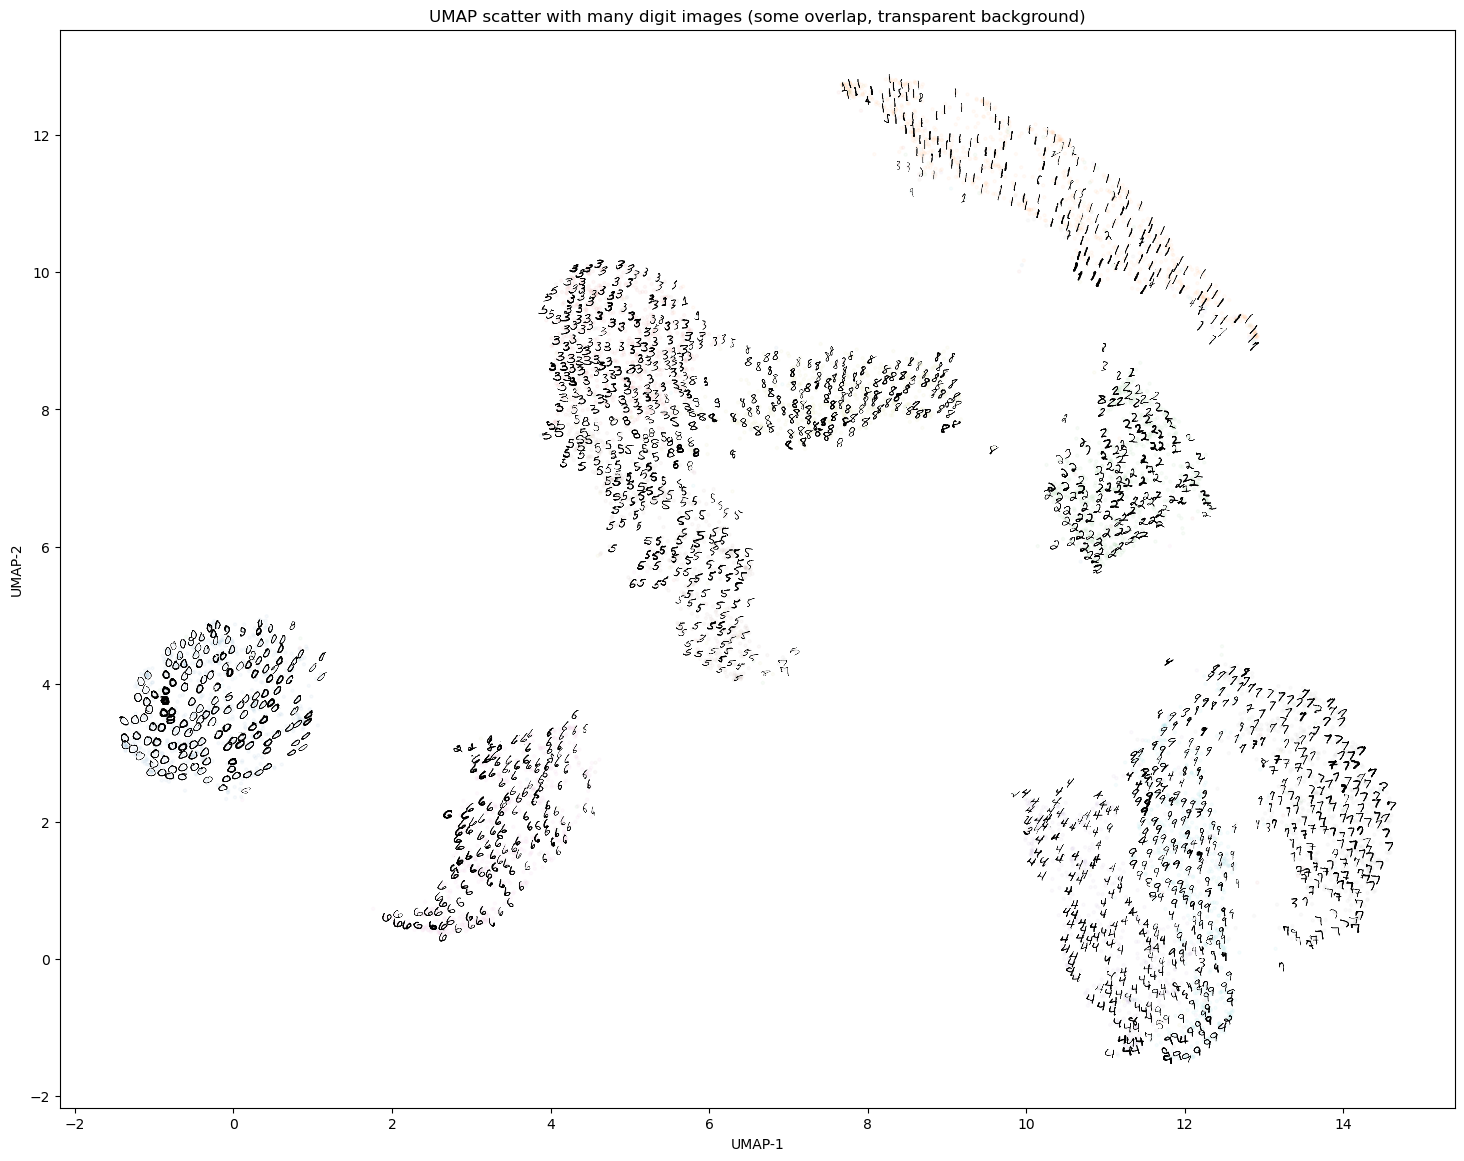

In [12]:
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
import numpy as np

N_ATTEMPT = 4000  # Try to plot up to 4000 digits
MIN_DIST = 0.1    # Allow some overlap (smaller minimum distance)
idx_attempt = np.random.choice(X_train.shape[0], N_ATTEMPT, replace=False)

fig, ax = plt.subplots(figsize=(18, 14))
ax.set_title('UMAP scatter with many digit images (some overlap, transparent background)')
ax.set_xlabel('UMAP-1')
ax.set_ylabel('UMAP-2')

ax.scatter(Z_train[:,0], Z_train[:,1], c=y_train, s=5, alpha=0.03, cmap='tab10')

plotted = []
for i in idx_attempt:
    xy = Z_train[i]
    if plotted:
        dists = np.linalg.norm(np.array(plotted) - xy, axis=1)
        if np.any(dists < MIN_DIST):
            continue  # Skip if too close to any already plotted image
    img = X_train[i].reshape(28, 28)
    img = 1.0 - img
    rgba_img = np.zeros((28, 28, 4))
    rgba_img[..., 0] = img
    rgba_img[..., 1] = img
    rgba_img[..., 2] = img
    rgba_img[..., 3] = (img < 0.95).astype(float)
    imagebox = OffsetImage(rgba_img, zoom=1.0/3.0)
    ab = AnnotationBbox(imagebox, xy, frameon=False)
    ax.add_artist(ab)
    plotted.append(xy)

ax.update_datalim(np.array(plotted))
ax.autoscale_view()
plt.show()

/usr/local/Caskroom/miniforge/base/envs/faiss_env/lib/python3.9/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


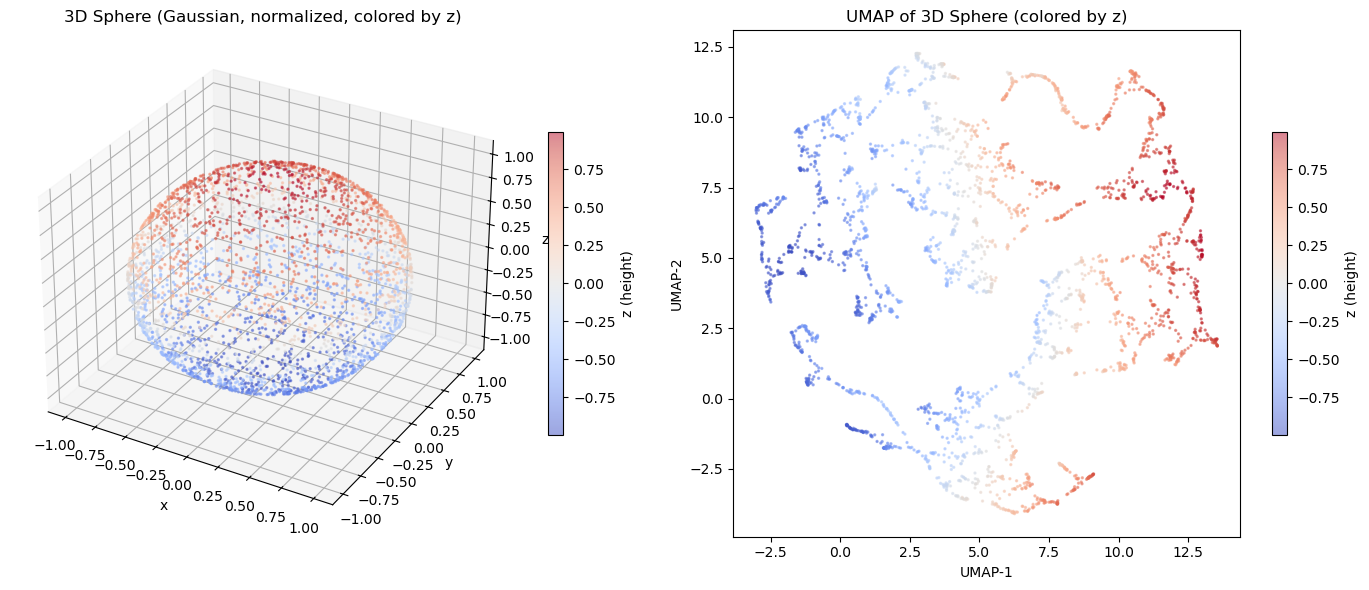

In [19]:
# Generate points on a 3D sphere by sampling from a 3D Gaussian and normalizing, then run UMAP
import numpy as np
import matplotlib.pyplot as plt
import umap.umap_ as umap
from mpl_toolkits.mplot3d import Axes3D

# Parameters
N_SPHERE = 3000  # number of points
SEED_SPHERE = 12
np.random.seed(SEED_SPHERE)

# Generate points from a 3D standard normal and normalize to unit length
X_raw = np.random.randn(N_SPHERE, 3)
X_sphere = X_raw / np.linalg.norm(X_raw, axis=1, keepdims=True)
x, y, z = X_sphere[:,0], X_sphere[:,1], X_sphere[:,2]

# Color by z axis value
colors = z  # color by height on the sphere

# Run UMAP to 2D
umap_sphere = umap.UMAP(n_neighbors=15, min_dist=0.1, n_components=2, random_state=SEED_SPHERE)
Z_sphere = umap_sphere.fit_transform(X_sphere)

# Plot side by side
fig = plt.figure(figsize=(14,6))
ax1 = fig.add_subplot(1, 2, 1, projection='3d')
sc1 = ax1.scatter(x, y, z, c=colors, cmap='coolwarm', s=2,alpha=0.5)
ax1.set_title('3D Sphere (Gaussian, normalized, colored by z)')
ax1.set_xlabel('x')
ax1.set_ylabel('y')
ax1.set_zlabel('z')
fig.colorbar(sc1, ax=ax1, shrink=0.6, label='z (height)')

ax2 = fig.add_subplot(1, 2, 2)
sc2 = ax2.scatter(Z_sphere[:,0], Z_sphere[:,1], c=colors, cmap='coolwarm', s=2, alpha=0.5)
ax2.set_title('UMAP of 3D Sphere (colored by z)')
ax2.set_xlabel('UMAP-1')
ax2.set_ylabel('UMAP-2')
fig.colorbar(sc2, ax=ax2, shrink=0.6, label='z (height)')
plt.tight_layout()
plt.show()